In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_excel('/Users/amirmojab/Desktop/ML Course/ml_samples.xlsx', sheet_name='salary')

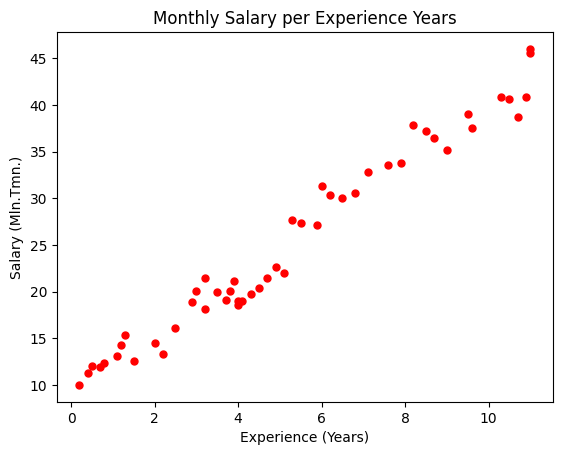

In [3]:
ax = plt.subplot()
ax.scatter(x=df['experience_years'],
           y=df['salary_linear'],
           c='r', 
           s=25)
ax.set_title('Monthly Salary per Experience Years')
ax.set_xlabel('Experience (Years)')
ax.set_ylabel('Salary (Mln.Tmn.)')
plt.show()

In [4]:
# Defining model objects with HYPERPARAMETERS
model_intercept = LinearRegression(fit_intercept=True)
model_no_intercept = LinearRegression(fit_intercept=False)

# Fitting the models to find out the best PARAMETERS
model_intercept.fit(
    X=df['experience_years'].to_numpy().reshape(-1, 1),
    y=df['salary_linear']
)

model_no_intercept.fit(
    X=df['experience_years'].to_numpy().reshape(-1, 1),
    y=df['salary_linear']
)


LinearRegression(fit_intercept=False)

In [5]:
# Printing PARAMETERS of the models
print(f'The model with fit_intercept=True:\tCoefficient: {round(model_intercept.coef_[0], 2)}\tIntercept: {round(model_intercept.intercept_, 2)}')
print(f'The model with fit_intercept=False:\tCoefficient: {round(model_no_intercept.coef_[0], 2)}\tIntercept: {round(model_no_intercept.intercept_, 2)}')

The model with fit_intercept=True:	Coefficient: 3.11	Intercept: 9.03
The model with fit_intercept=False:	Coefficient: 4.36	Intercept: 0.0


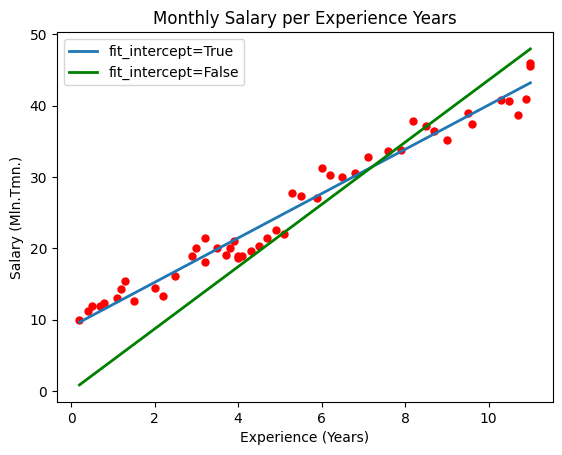

In [6]:
ax = plt.subplot()
ax.scatter(x=df['experience_years'],
           y=df['salary_linear'],
           c='r',
           s=25)

# y = a * x + b
# y = coefficient * x + intercept
x_fit =                 df['experience_years']
y_fit_intercept =       model_intercept.coef_ * x_fit + model_intercept.intercept_
y_fit_no_intercept =    model_no_intercept.coef_ * x_fit + model_no_intercept.intercept_

ax.plot(x_fit, y_fit_intercept, lw=2, label='fit_intercept=True')
ax.plot(x_fit, y_fit_no_intercept, c='g', lw=2, label='fit_intercept=False')
ax.set_title('Monthly Salary per Experience Years')
ax.set_xlabel('Experience (Years)')
ax.set_ylabel('Salary (Mln.Tmn.)')
plt.legend(loc='upper left')
plt.show()

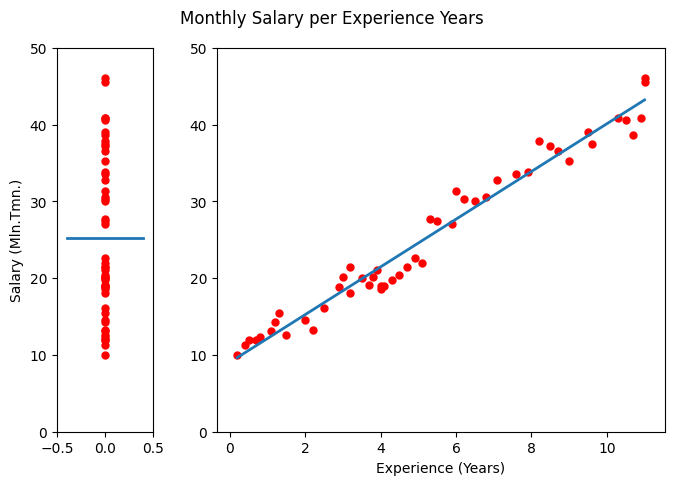

In [7]:
left, width, bottom, height = 0.07, 0.15, 0.1, 0.8
bottom_h = left_h = left + width + 0.1

fig = plt.figure()
plt.suptitle('Monthly Salary per Experience Years')

fig_left = plt.axes((left, bottom, width, height))

# Plotting just salary values
fig_left.scatter(x=[0] * 50,
                 y=df['salary_linear'],
                 c='r',
                 s=25)

# Plotting the mean of y-axis as a line
x_mean = np.linspace(-0.4, 0.4, 9)
y_mean = df['salary_linear'].mean()

fig_left.plot(x_mean, [y_mean] * 9, lw=2)

plt.xlim(-0.5, 0.5)
plt.ylim(0, 50)
plt.ylabel('Salary (Mln.Tmn.)')

# Plotting regular scatter
fig_right = plt.axes((left_h, bottom, 0.7, height))

fig_right.scatter(x=df['experience_years'],
                  y=df['salary_linear'],
                  c='r',
                  s=25)

fig_right.plot(x_fit, y_fit_intercept, lw=2)

plt.ylim(0, 50)
plt.xlabel('Experience (Years)')

plt.show()

In [140]:
# Calculating R-Squared
x = df['experience_years'].to_numpy().reshape(-1, 1)

y_fit_intercept =       model_intercept.coef_     * x + model_intercept.intercept_
y_fit_no_intercept =    model_no_intercept.coef_  * x + model_no_intercept.intercept_

sum_sq_mean =               ((df['salary_linear'].to_numpy() - df['salary_linear'].mean()) ** 2).sum()
sum_sq_fit_intercept =      ((df['salary_linear'].to_numpy().reshape(-1, 1) - y_fit_intercept) ** 2).sum()
sum_sq_fit_no_intercept =   ((df['salary_linear'].to_numpy().reshape(-1, 1) - y_fit_no_intercept) ** 2).sum()

# R-Squared formula: 1 - (Var_Fit) / (Var_Fit)
r2_intercept =      1 - (sum_sq_fit_intercept / sum_sq_mean)
r2_no_intercept =   1 - (sum_sq_fit_no_intercept / sum_sq_mean)

print(f'R-Squared for the model with fit_intercept=True:\t{round(r2_intercept, 2)}')
print(f'R-Squared for the model with fit_intercept=False:\t{round(r2_no_intercept, 2)}')

R-Squared for the model with fit_intercept=True:	0.97
R-Squared for the model with fit_intercept=False:	0.75


In [141]:
# Using SKLearn Metrics
r2_intercept = r2_score(y_true=df['salary_linear'].to_numpy().reshape(-1, 1), y_pred=y_fit_intercept)
r2_fit_no_intercept = r2_score(y_true=df['salary_linear'].to_numpy().reshape(-1, 1), y_pred=y_fit_no_intercept)

print(f'R-Squared for the model with fit_intercept=True:\t{round(r2_intercept, 2)}')
print(f'R-Squared for the model with fit_intercept=False:\t{round(r2_fit_no_intercept, 2)}')

R-Squared for the model with fit_intercept=True:	0.97
R-Squared for the model with fit_intercept=False:	0.75


In [142]:
# Using SKLearn Metrics
mse_intercept = mean_squared_error(y_true=df['salary_linear'].to_numpy().reshape(-1, 1), y_pred=y_fit_intercept)
mse_fit_no_intercept = mean_squared_error(y_true=df['salary_linear'].to_numpy().reshape(-1, 1), y_pred=y_fit_no_intercept)

print(f'MSE for the model with fit_intercept=True:\t{round(mse_intercept, 2)}')
print(f'MSE for the model with fit_intercept=False:\t{round(mse_fit_no_intercept, 2)}')

MSE for the model with fit_intercept=True:	3.33
MSE for the model with fit_intercept=False:	26.07
